In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd



In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
imgage_size=(150,150)
batch_size=32

In [4]:
train_datagen=ImageDataGenerator(rescale=1/255,
                                 shear_range=0.2, #check more option

                                 )

test_datagen=ImageDataGenerator(rescale=1/255,
                                 shear_range=0.2, #check more option
                                 )

In [5]:
training_set=train_datagen.flow_from_directory('/content/drive/MyDrive/cat_rabbit/train-cat-rabbit',
                                               target_size=imgage_size,
                                               batch_size=batch_size,
                                               class_mode='binary')


test_set=train_datagen.flow_from_directory('/content/drive/MyDrive/cat_rabbit/test-images',
                                               target_size=imgage_size,
                                               batch_size=batch_size,
                                               class_mode='binary')

Found 1600 images belonging to 2 classes.
Found 15 images belonging to 2 classes.


In [6]:
model=keras.Sequential(
    [

        keras.layers.Conv2D(32,(3,3), activation='relu',input_shape=(150,150,3)),

        keras.layers.MaxPooling2D((3,3)),
        keras.layers.Conv2D(32,(3,3), activation='relu'),
        keras.layers.MaxPooling2D((3,3)),
        keras.layers.Conv2D(32,(3,3), activation='relu'),
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation='relu',),
        keras.layers.Dense(1, activation='sigmoid'),

     ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',metrics=['accuracy']


)


history = model.fit(
    training_set,
    epochs=20,
    validation_data=test_set
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 196s 4s/step - accuracy: 0.6506 - loss: 0.6081 - val_accuracy: 0.7333 - val_loss: 0.5181
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 409ms/step - accuracy: 0.7450 - loss: 0.5034 - val_accuracy: 0.9333 - val_loss: 0.2561
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 359ms/step - accuracy: 0.8331 - loss: 0.3832 - val_accuracy: 1.0000 - val_loss: 0.1744
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 355ms/step - accuracy: 0.8444 - loss: 0.3381 - val_accuracy: 1.0000 - val_loss: 0.2587
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 372ms/step - accuracy: 0.8881 - loss: 0.2654 - val_accuracy: 1.0000 - val_loss: 0.1293
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 371ms/step - accuracy: 0.9269 - loss: 0.1891 - val_accuracy: 1.0000 - val_loss: 0.1198
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 378ms/step - accuracy: 0.9475 - loss: 0.1362 - val_accuracy: 0.9333 - val_loss: 0.1286
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 366ms/step - accuracy: 0.9531 - loss: 0.1293 - val_accura

In [8]:
test_loss, test_acc = model.evaluate(test_set)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9333 - loss: 0.8096
Test Loss: 0.8096107244491577
Test Accuracy: 0.9333333373069763


In [9]:
y_pred = model.predict(test_set)
import numpy as np

y_pred = np.argmax(y_pred, axis=1)
y_true = test_set.classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step


In [10]:
y_true

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=int32)

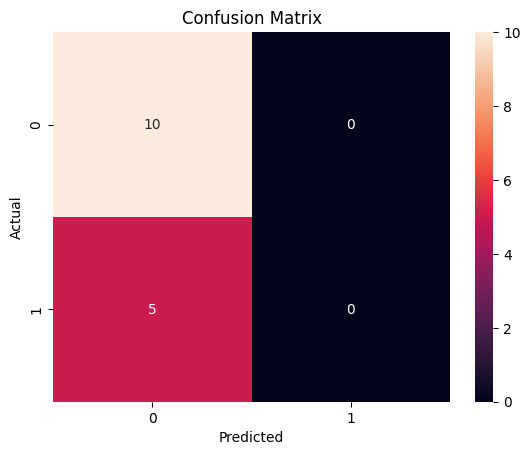

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.67      1.00      0.80        10
           1       0.00      0.00      0.00         5

    accuracy                           0.67        15
   macro avg       0.33      0.50      0.40        15
weighted avg       0.44      0.67      0.53        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


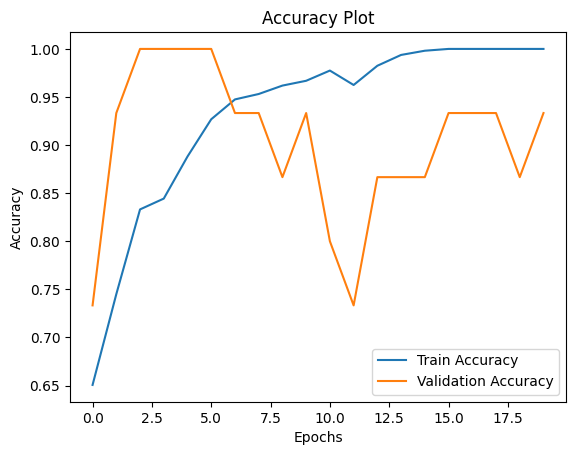

In [13]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Plot')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [14]:
model.save_weights('cat_rabbit.weights.h5')

In [15]:
'''Blue line = model getting too perfect on training data
Orange line = model struggling on new data
Conclusion = Overfitting problem'''